In this notebook:

1. **Confusion Matrix**
2. **The Effect of Tuning Hyperparameters**

Output:
- **Saved Model Parameters for Deployment**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilities_notebook import load_ml_data, sigmoid, compute_cost, compute_gradient, run_gradient_descent, predict, zscore_normalize_features, apply_zscore_normalization, evaluate_classification_performance, evaluate_classification_performance_2

Loaded data from: linear
X_train: (567, 6), y_train: (567, 1)
X_test : (144, 6), y_test : (144, 1)

Iteration    0: Cost  0.68841
Iteration 1000: Cost  0.64143
Iteration 2000: Cost  0.64141
Iteration 3000: Cost  0.64141
Iteration 4000: Cost  0.64141
Iteration 5000: Cost  0.64141
Iteration 6000: Cost  0.64141
Iteration 7000: Cost  0.64141
Iteration 8000: Cost  0.64141
Iteration 9000: Cost  0.64141
Iteration 9999: Cost  0.64141


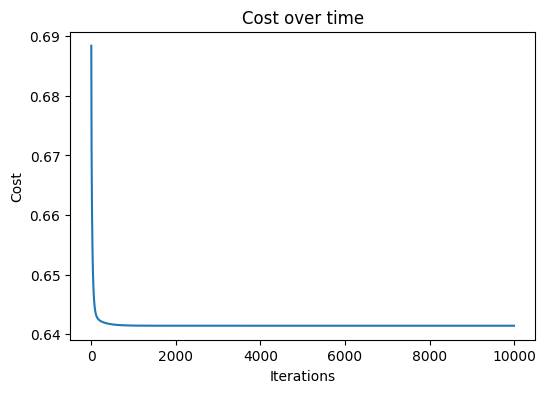

In [2]:
# Load and train linear logistic regression model

X_train, X_test, y_train, y_test = load_ml_data("../data", "linear")
features = ['volume', 'pct_change_1d', 'rsi', 'adx']
X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns=features)
w_in = np.zeros(X_train_norm.shape[1])
b_in = 0

w, b = run_gradient_descent(X_train_norm.values, y_train.values.reshape(-1), w_in, b_in, compute_cost,
                            compute_gradient, alpha=0.1, num_iters=10000, lambda_=0)
f_wb, p = predict(X_train_norm, w, b)

## 1 Confusion Matrix

- Evaluating the linear logistic regression model
- Evaluating the polynomial logistic regression model

The models are first evaluated on the training set.

#### Evaluating the linear logistic regression model

In [3]:
def get_confusion_matrix(y_test, true_col='signal', pred_col='pred'):
    """
    Calculates the TN, FP, FN, TP from a (m, 2) DataFrame where the first column
    are the true labels, and the second column are the predicted labels, and m is
    the number of samples
    """
    positive = y_test[y_test[true_col] == 1] # filter dataframe by true positive labels
    negative = y_test[y_test[true_col] == 0] # filter dataframe by true negative labels

    # True Negatives: # y_true=0, y_pred=0
    TN = len(negative[negative[pred_col] == 0])
    # False Positives: # y_true=0, y_pred=1
    FP = len(negative[negative[pred_col] == 1])
    # False Negatives: # y_true=1, y_pred=0
    FN = len(positive[positive[pred_col] == 0])
    # True Positives: # y_true=1, y_pred=1
    TP = len(positive[positive[pred_col] == 1])

    return TN, FP, FN, TP

In [4]:
def plot_confusion_matrix(y_true, y_pred, confusion_matrix_plot_f):
    """
    Args:
        y_pred (ndarray or Series (m,)) : predicted labels from a classifier
    """
    confusion_matrix_plot_f(y_true, y_pred)
    plt.show()

In the cell below:
- Show that our manual implementation of the confusion matrix is equivalent to Scikit-learn's
- Obtain confusion matrix metrics for our linear logistic regression model
- Plot the confusion matrix using Scikit-learn's ConfusionMatrixDisplay class

Confusion matrix scikit-learn's implementation - TN: 283, FP: 52, FN: 165, TP: 67, Total Count = 567

TPR: 0.289, TNR: 0.845
Precision: 0.563, NPV: 0.632


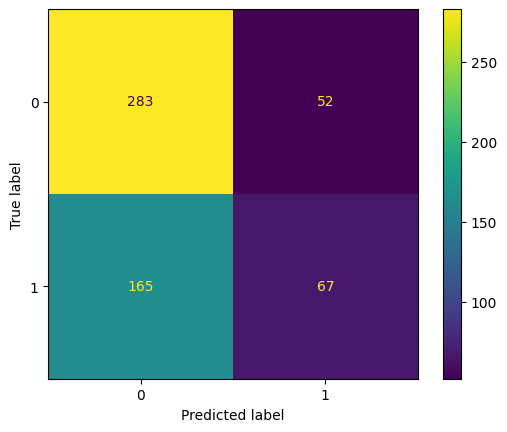

In [5]:
y_train['pred'] = p.reshape((-1, 1))

TN, FP, FN, TP = get_confusion_matrix(y_train)

# check confusion matrix metrics with scikit-learn's confusion matrix implementation
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_train['signal'], p).ravel().tolist() 

print(f"Confusion matrix scikit-learn's implementation - TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}, Total Count = {tn+fp+fn+tp}\n")

# detailed classification metrics
TPR = TP / (TP+FN) # True Positive Rate (Sensitivity/Recall) = TP / (TP+FN)
TNR = TN / (TN+FP) # True Negative Rate (Specificity) = TN / (TN+FP)
print(f"TPR: {TPR:0.3f}, TNR: {TNR:0.3f}")

NPV = TN / (TN+FN) # Negative Predictive Value
precision = TP / (TP+FP) # Precision: accuracy of the positive predictions
print(f"Precision: {precision:0.3f}, NPV: {NPV:0.3f}")

# display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

plot_confusion_matrix(y_train['signal'], p, ConfusionMatrixDisplay.from_predictions)

The linear logistic regression model shows that with a decision threshold of 0.5 for predicting the positive class, it leans on the conservative side.

**The Precision** (0.56) is better than a random coin flip (0.50), showing that its positive predictions are correct 56% of the time. For our application, it correctly predicts more than half of the time that the next day close price will be higher than the previous day close price.

**The Recall (or True Positive Rate)** (0.29) however is very low. The model will tend to predict that the next day close will decrease or have no change. A value of 0.29 indicates that even though the next day close price will increase, the model correctly predicts it will increase only 29% of the time.

**The True Negative Rate (TNR)** of 0.85 is very high, showing that it predicts negative samples with an 85% accuracy. Or in our application, it correctly predicts 85% of the time that the next day close price will indeed be lower or have no change from the previous close price.

The low Recall and high TNR shows the model's conservatism when predicting an increase for the next day close price. It will rather predict that price will decrease or have no change than predict an increase.

In [6]:
def plot_confusion_matrix_at_thresholds(y_true, y_score, confusion_matrix_at_thresholds):
    """
    Plots the TN, FP, FN, TP of a classifier at different thresholds

    Args:
        y_true (ndarray or Series (m,))             : true labels with m samples
        y_score (ndarray or Series (m,))            : threshold probabilities of m samples being the positive class
        confusion_matrix_at_thresholds (function)   : Scikit-learn function that computes the TNs, FPs, FNs, TPs,
                                                      and threshold values for binary classification
    """
    tns, fps, fns, tps, threshold = confusion_matrix_at_thresholds(y_true, y_score)

    # Plot TNs, FPs, FNs and TPs vs Thresholds
    plt.figure(figsize=(10, 6))

    plt.plot(threshold, tns, label="True Negatives (TNs)")
    plt.plot(threshold, fps, label="False Positives (FPs)")
    plt.plot(threshold, fns, label="False Negatives (FNs)")
    plt.plot(threshold, tps, label="True Positives (TPs)")
    plt.xlabel("Thresholds")
    plt.ylabel("Count")
    plt.title("TNs, FPs, FNs and TPs vs Thresholds")
    plt.legend()
    plt.grid()

    plt.show()

In [7]:
def plot_precision_call_vs_threshold(y_true, y_score, precision_recall_curve_f):
    """
    Plots the precision-recall curve at different thresholds
    """

    precisions, recalls, thresholds = precision_recall_curve_f(y_true, y_score)

    plt.plot(thresholds, precisions[:-1], 'b--', label='precision')
    plt.plot(thresholds, recalls[:-1], 'g--', label='recall')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Threshold')
    plt.ylabel('Values (between 0 and 1)')
    plt.legend()
    plt.show()

In [8]:
def plot_roc_curve(y_true, y_score, roc_curve_f, roc_auc_score_f):
    fpr, tpr, thresholds = roc_curve_f(y_true, y_score)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve (AUC Score: {roc_auc_score_f(y_true, y_score):0.3f})')
    plt.legend()
    plt.show()
    

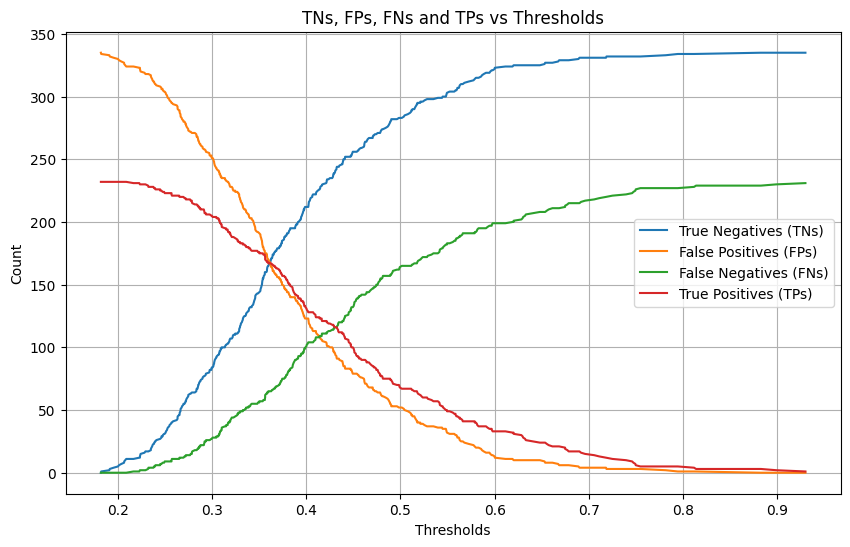

In [9]:
from sklearn.metrics import confusion_matrix_at_thresholds

plot_confusion_matrix_at_thresholds(y_train['signal'], f_wb, confusion_matrix_at_thresholds)

The plot above shows how the TNs, FPs, FNs, TPs vary as the decision threshold varies from 0 to 1.

At 0, the model predicts all 'probabilities' of $f_{w,b}(x)$ as the positive class and thus all samples would either be True Positives or False Positives.

At 1, the model predicts all 'probabilities' of $f_{w,b}(x)$ as the negative class and thus all samples would either be True Negatives or False Negatives.

As the decision threshold increases from 0 to 1, the model becomes less optimistic or more cautious in predicting the positive class. There will be trade-off between the confusion matrix metrics and so a balance can be found by tuning the hyperparameter to suit our needs.

For example, we might want the model to be more optimistic to enter a long position if used as a trading algorithm so we can tune the hyperparameter to a lower threshold.

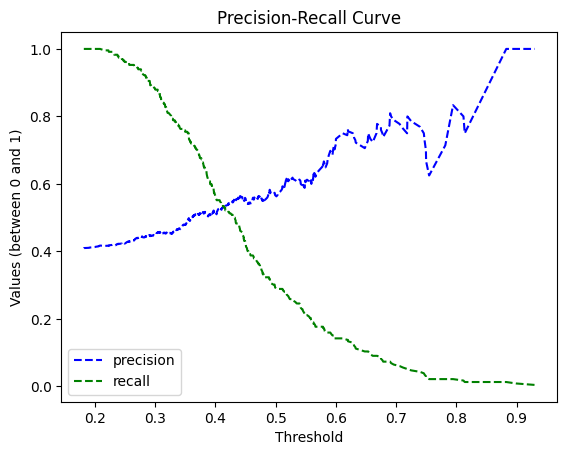

In [10]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

plot_precision_call_vs_threshold(y_train['signal'], f_wb, precision_recall_curve)

As the decision threshold increases, the model predicts the positive class only when the 'probability' of the sample being positive is high, making True Positives higher and False Positives lower. Therefore, precision increases.

However, as the model's cautiousness increases, actual positive labels being classed as negative increases making False Negatives higher and True Positives lower. Therefore, recall decreases.

This tradeoff can be tuned for the application depending on whether precision or recall is more important. 

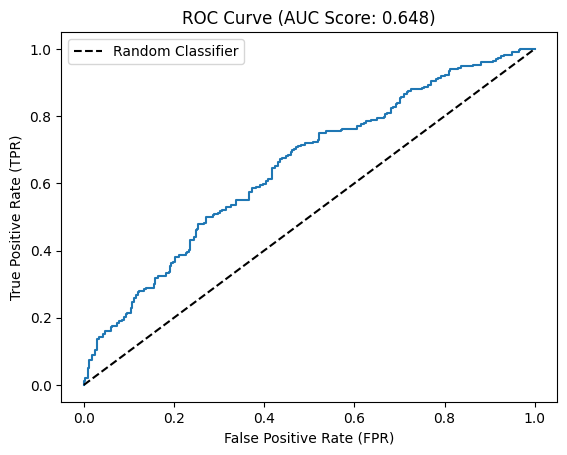

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

plot_roc_curve(y_train['signal'], f_wb, roc_curve, roc_auc_score)


The ROC curve is a metric that shows how well a classifier performs across all possible decision thresholds. An ideal classifier is one that stretches all the way to the top-left corner with a TPR of 1 and FPR of 0.

The AUC score computes the area under the ROC curve and is a measure of a classification performance invariant of the decision threshold. The ideal classifier has an AUC score of 1 and any classifier lower than 0.5 would be a worse classifier than a random coin flip (0.5).

The linear regression model here has a score of 0.648 which is okay.

___
#### Evaluating the polynomial logistic regression model

The same process is repeated for the polynomial logistic regression model.

Loaded data from: poly
X_poly_train: (562, 27), y_poly_train: (562, 1)
X_poly_test : (144, 27), y_poly_test : (144, 1)

Iteration    0: Cost  0.68480
Iteration 5000: Cost  0.63055
Iteration 10000: Cost  0.63002
Iteration 15000: Cost  0.62976
Iteration 20000: Cost  0.62958
Iteration 25000: Cost  0.62946
Iteration 30000: Cost  0.62937
Iteration 35000: Cost  0.62930
Iteration 40000: Cost  0.62925
Iteration 45000: Cost  0.62921
Iteration 49999: Cost  0.62917


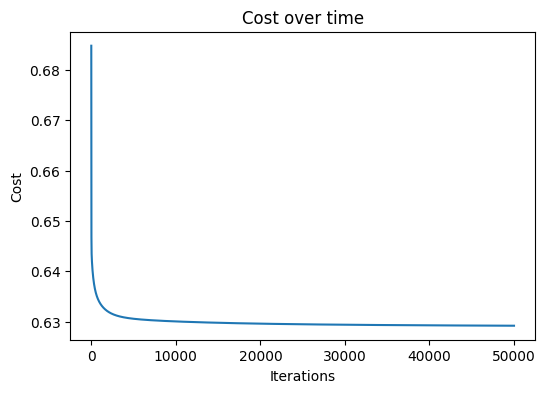

In [12]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = load_ml_data("../data", "poly")

exclude = ['corr', 'volatility', 'corr^2', 'pct_change_1d*volatility']
cols_to_scale = [c for c in X_poly_train.columns if c not in exclude]
X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns=cols_to_scale)

w2_in = np.zeros(X_poly_train_norm.shape[1])
b2_in = 0
w2, b2 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w2_in, b2_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=0)

f_wb3, p3 = predict(X_poly_train_norm, w2, b2)

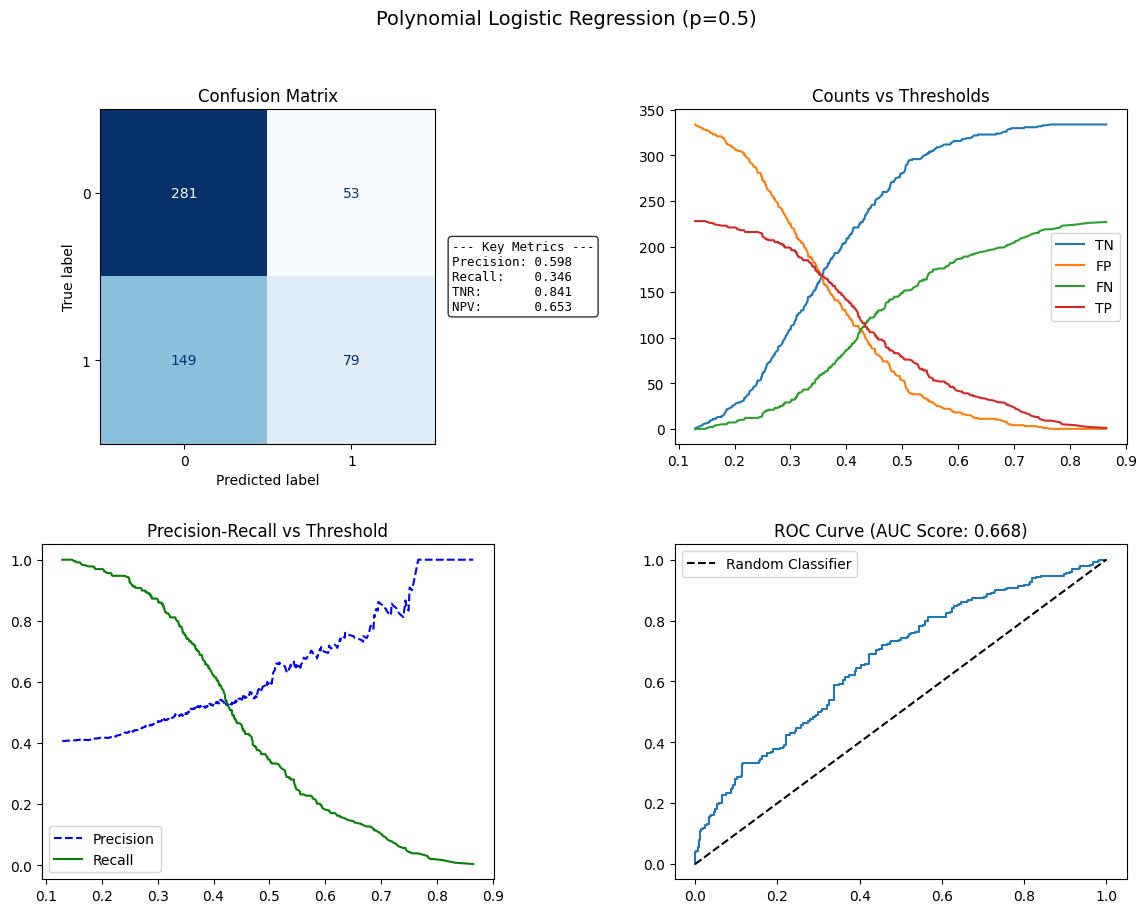

In [13]:
evaluate_classification_performance_2(y_poly_train, p3, f_wb3,
                                      confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Polynomial Logistic Regression (p=0.5)')

The polynomial logistic regression model seems to be a better classifier with an AUC (Area under Curve) score for the ROC curve of 0.668 compared with the linear logistic regression model's AUC score of 0.648.

But this is expected as the polynomial model should be expected to fit more tightly to the training set.

What actually matters is the final AUC score on the test set which tests generalizability of the model on unseen data.
___

## 2 Effect of Tuning Hyperparameters

- Linear logistic regression
- Polynomial logistic regression
- Regularized polynomial logistic regression

Two hyperparameters are tuned here:
1. The decision threshold for binary classification of $f_{w,b}(\mathbf{x})$
2. Regularization parameter for polynomial logistic regression

The decision threshold is tuned from our investigations of the confusion matrix above before evaluating the classification models on the test set. This is showed with the linear logistic regression model and the polynomial logistic regression model.

The effect of regularization is shown by tuning the regularization parameter of the existing polynomial logistic regression model.

#### Linear Logistic Regression

In [14]:
# apply z-score normalization with mean and standard deviation values calculated from the train set
X_test_norm = apply_zscore_normalization(X_test, X_train_mu, X_train_sigma, columns=features) 
f_wb2, p2 = predict(X_test_norm, w, b, p=0.4)

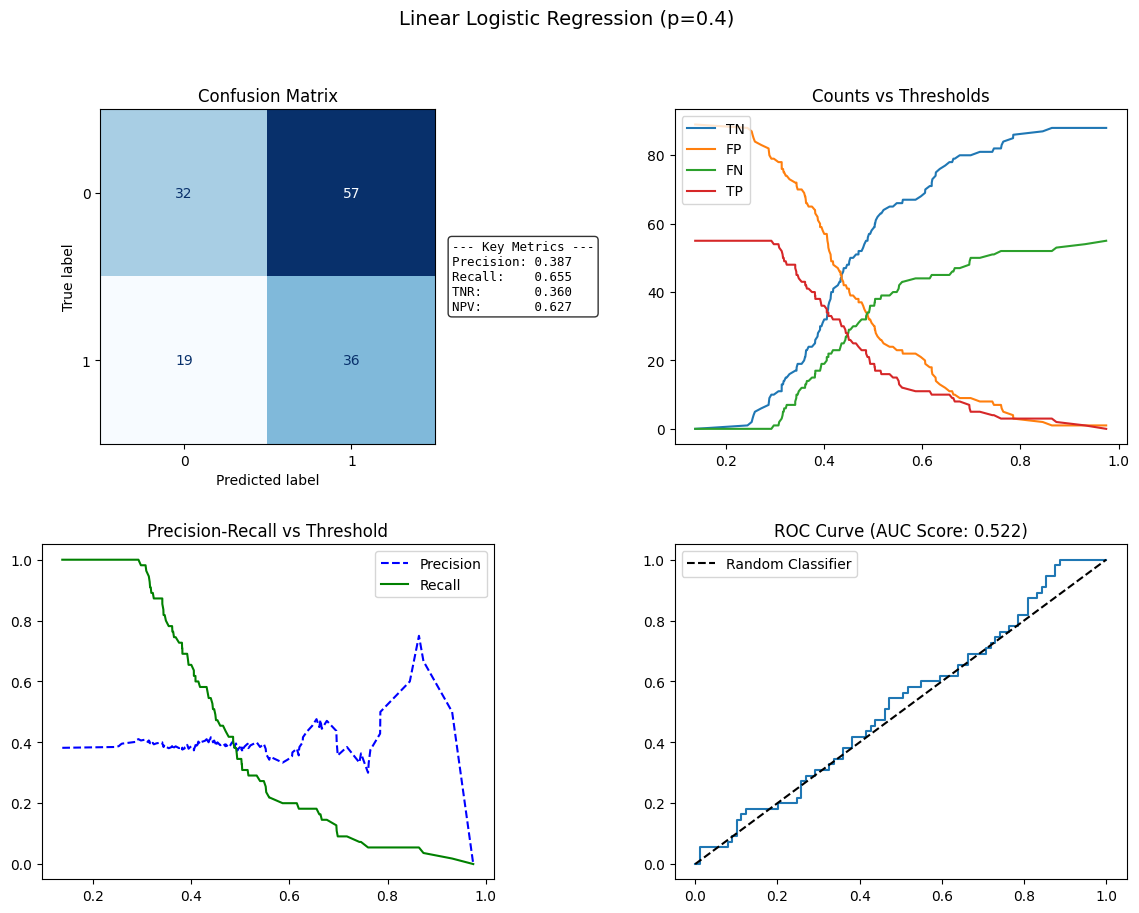

In [15]:
evaluate_classification_performance_2(y_test, p2, f_wb2,
                                      confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Linear Logistic Regression (p=0.4)')



#### Polynomial Logistic Regression

The same process is repeated for the polynomial logistic regression model with a slightly different decision threshold of 0.42.

In [16]:
X_poly_test_norm = apply_zscore_normalization(X_poly_test, X_poly_train_mu, X_poly_train_sigma, cols_to_scale)
f_wb4, p4 = predict(X_poly_test_norm, w2, b2, p=0.42)

print(f"Test Accuracy: {np.mean(p4 == y_poly_test['signal'].values) * 100:0.2f}%")

Test Accuracy: 51.39%


Test accuracy increased slightly from 50.69% to 51.39% but this is trivial.

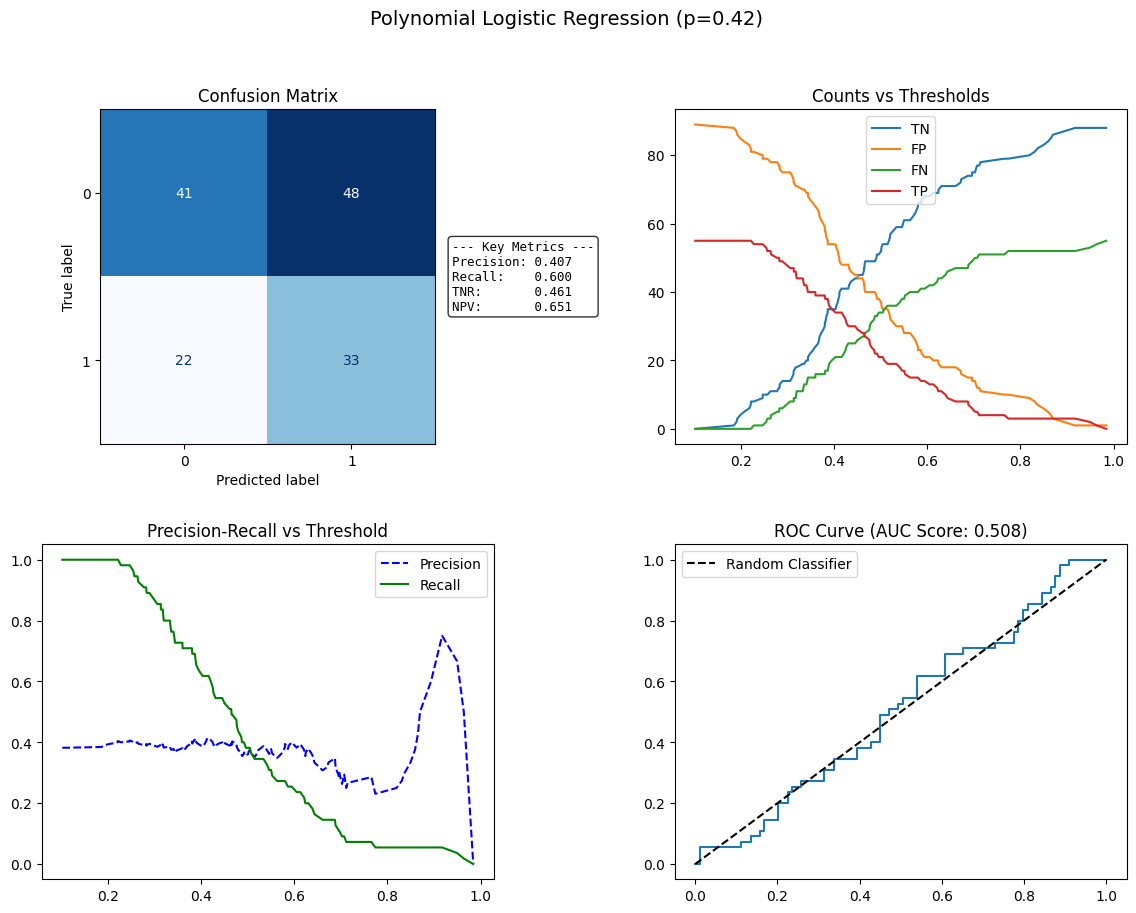

In [17]:
evaluate_classification_performance_2(y_poly_test, p4, f_wb4,
                                      confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Polynomial Logistic Regression (p=0.42)')

As seen above, both AUC scores for the linear logistic regression model and the polynomial logistic regression model have dropped significantly with an AUC score of 0.522 for the former and an AUC score of 0.508 for the latter.

For other applications such as medical diagnosis, these classifiers would be considered terrible and not usable in any form. However, for financial applications such as predicting stock price, a classifier that is only slightly better than a coin flip is still bad but it is not uncommon, as classifiers with high AUC scores quickly get discovered and its edge slowly dissipates as more market participants use the same model.
___

#### Regularized Polynomial Logistic Regression

In the two models above, the simpler linear model edges out as a slightly better classifier than polynomial logistic regression.

However, polynomial features causes the model to have a tighter fit on the training data which might lead to overfitting and thus poorer generalization to the test data.

Applying regularization to the polynomial model penalizes the large coefficients of the model and thus reduces the effect of overfitting. Let us investigate if this produces a better classifier overall.

The regularization parameter is set to 20. A higher value increases penalizes the model coefficients more.

Iteration    0: Cost  0.68481
Iteration 5000: Cost  0.64195
Iteration 10000: Cost  0.64194
Iteration 15000: Cost  0.64194
Iteration 20000: Cost  0.64194
Iteration 25000: Cost  0.64194
Iteration 30000: Cost  0.64194
Iteration 35000: Cost  0.64194
Iteration 40000: Cost  0.64194
Iteration 45000: Cost  0.64194
Iteration 49999: Cost  0.64194


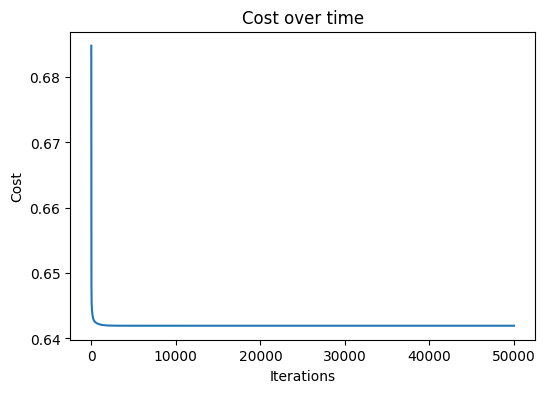

Train accuracy: 62.81%
Test Accuracy: 52.78%


In [18]:
w3_in = np.zeros(X_poly_train_norm.shape[1])
b3_in = 0
w3, b3 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w3_in, b3_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=20)

f_wb5, p5 = predict(X_poly_train_norm, w3, b3, p=0.46) # computed just to see train accuracy of regularized polynomial logistic regression
print(f"Train accuracy: {np.mean(p5==y_poly_train['signal'].values) * 100:0.2f}%")

f_wb6, p6 = predict(X_poly_test_norm, w3, b3, p=0.46)
print(f"Test Accuracy: {np.mean(p6 == y_poly_test['signal'].values) * 100:0.2f}%")

Train accuracy is slightly lower from the unregularized version from 63.70% to 62.81%, whereas test accuracy has a slight increase from 51.39% to 52.78%.

This is expected as regularization reduces overfitting to training data which should lead to better generalization overall to unseen data.

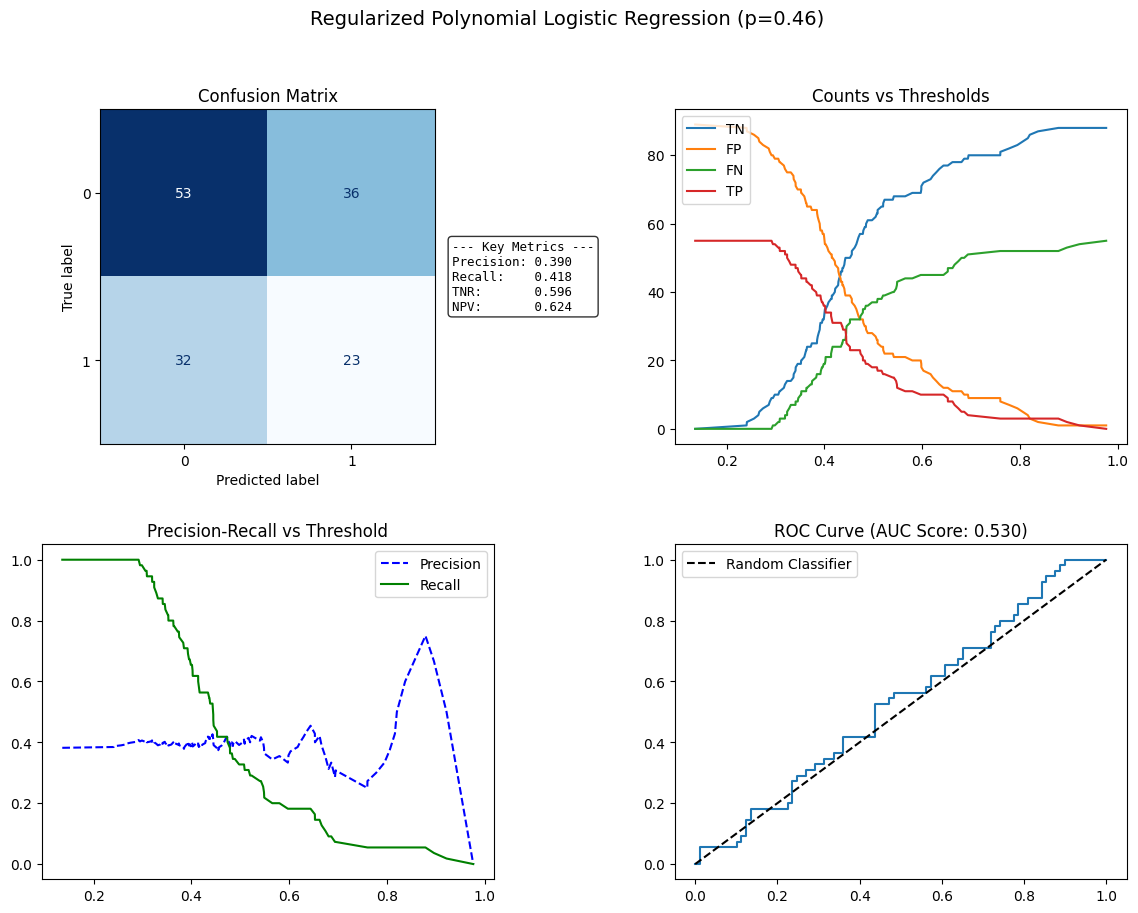

In [19]:
evaluate_classification_performance_2(y_poly_test, p6, f_wb6,
                                      confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Regularized Polynomial Logistic Regression (p=0.46)')

As expected, the regularized polynomial regression model performs slightly better now compared to its linear counterpart with an AUC score of 0.530.

The unregularized linear and polynomial models show significant drop in AUC scores from ~0.66 to ~0.51. This suggests that our models may have fitted to noise rather than actually capturing true patterns in the data.

However, for elementary models, being able to predict prices better than a random coin flip shows some upside for better models through more advanced methods.

And for financial timeseries forecasting, even AUC scores as low as 0.50s may allow for some edge in the markets.

In [20]:
import pickle

# save the weights and bias of the regularized polynomial logistic regression model
model_manual = {
    'weights':w3,
    'bias':b3,
    'mu':X_poly_train_mu,
    'sigma':X_poly_train_sigma,
    'features_to_scale':cols_to_scale
}

with open('../model.pkl', 'wb') as f:
    pickle.dump(model_manual, f)

Final verdict: Regularized Logistic Regression was chosen as the final model for deployment with ROC of 0.530.